In [ ]:
!pip install transformers accelerate peft bitsandbytes torch --upgrade

from transformers import Blip2Processor, Blip2ForConditionalGeneration, LlamaForCausalLM, LlamaTokenizer
import torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 149.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 35.5 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.56.2
    Uninstalling transformers-4.56.2:
      Successfully uninstalled transformers-4.56.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


This is one example before cleaning:  
  Ground Truth: Auf der Schulter Lotos-Palmettenornament zwischen zwei Hunden. Auf dem Bauch auf Klappstühlen einander zugewandt ein sitzender Jüngling, den Mantel um die Hüfte geschlagen, auf dem Kopf einen Kranz, und ein sitzender bekleideter Bärtiger mit Stab, wohl zwei Kampfrichter. Hinter den Stühlen je ein zur Gruppe gewendeter stehender nackter Speeträger und ein bärtiger abgewandter Bekleideter. Im Feld oberhalb des sitzenden Bärtigen ein aufgehängtes Gewandstück. Unterhalb des Henkels drei Hunde. Ton mit rotbraunem bis bräunlichschwarzem mattglänzendem Firnis / Glanzton, der teilweise abgeblättert ist. Nach: H. P. Isler, Corpus vasorum antiquorum. Schweiz 2, Zürich 1 (Bern 1973) 23–24 Taf. 17, 1–4. 14–16. Zur Kontextualisierung in der Literatur: H. P. Isler, Corpus vasorum antiquorum. Schweiz 2, Zürich 1 (Bern 1973) 23–24 Taf. 17, 1–4. 14–16.  
  Prediction:   Die spartanische Fussunterseite ist ein feines Gefäss. Eine ungewöhnliche Schranke (bei dem Auflauf einer Erden) isst auch mit einem Rücken des Fahrers auf die Oberfläche der Urheberfläche in der Mitte.

In [ ]:
import re
import pandas as pd

def clean_all_descriptions(df):
    """Clean all descriptions in the dataframe"""
    cleaned_df = df.copy()

    def clean_text(text):
        if not isinstance(text, str):
            return text
        # Remove citations and references
        text = re.split(r'Nach:|Zur Kontextualisierung', text)[0].strip()
        text = text.rstrip('., ')
        return text

    # Apply to Full Description column
    if 'Full Description' in cleaned_df.columns:
        cleaned_df['Full Description'] = cleaned_df['Full Description'].apply(clean_text)

    return cleaned_df

# Load and clean the data
CSV_PATH = "/content/drive/My Drive/master_thesis_project/uzh_metadata_0801.csv"
df_clean = clean_all_descriptions(pd.read_csv(CSV_PATH))

# Save cleaned version
CLEAN_CSV_PATH = "/content/drive/My Drive/master_thesis_project/uzh_metadata_0921.csv"
df_clean.to_csv(CLEAN_CSV_PATH, index=False)
print(f"Cleaned data saved to: {CLEAN_CSV_PATH}")

Cleaned data saved to: /content/drive/My Drive/master_thesis_project/uzh_metadata_0921.csv


In [ ]:
import os
import pandas as pd
from collections import defaultdict
from glob import glob

# Paths
CSV_PATH = "/content/drive/My Drive/master_thesis_project/uzh_metadata_0921.csv"
IMG_DIR  = "/content/drive/My Drive/master_thesis_project/uzh_images"

# Build artefact_id -> [image_paths]
image_map = defaultdict(list)
for path in glob(os.path.join(IMG_DIR, "*.*")):
    if path.lower().endswith((".jpg", ".jpeg", ".png")):
        fname = os.path.basename(path)
        artefact_id = fname.split("_")[0]  # assumes {ID}_*.jpg
        image_map[str(artefact_id)].append(path)

# Sort images per artefact for reproducibility
for k in image_map:
    image_map[k] = sorted(image_map[k])

# Load metadata
df = pd.read_csv(CSV_PATH)

# Normalize IDs to string
df["ID"] = df["ID"].astype(str)

# Keep only rows with available images
df = df[df["ID"].isin(image_map.keys())].reset_index(drop=True)

print(f"Total artifacts with images: {len(df)}")

Total artifacts with images: 495


In [ ]:
from PIL import Image
import torch

def collate_fn(batch, processor, image_size=(224, 224)):
    """
    Collate function for BLIP-2 with Flan-T5 - Fixed dtype consistency
    images are stacked together into tensors, but inside one batch, only when each sample has the same number of images, they can be stacked, so find the max number of images per batch, and then pad each sample with dummy gray images. For the images, there is an image_mask (1 for real images and 0 for padded images).
    """
    texts = [s["prompt"] for s in batch]
    targets = [s["target"] for s in batch]
    image_lists = [s["image_paths"] for s in batch]

    bs = len(batch)
    max_images = max(len(imgs) for imgs in image_lists)

    padded_images = []
    image_mask = []

    for imgs in image_lists:
        n = len(imgs)
        mask = [1] * n + [0] * (max_images - n)
        image_mask.append(mask)

        # Load images and pad with dummy gray images
        loaded = [Image.open(p).convert("RGB") for p in imgs]
        if n < max_images:
            loaded += [Image.new("RGB", image_size, "gray")] * (max_images - n)
        padded_images.extend(loaded)

    # Process all images at once - Keep in FP32 for consistency
    pixel_values = processor(images=padded_images, return_tensors="pt").pixel_values
    pixel_values = pixel_values.reshape(bs, max_images, *pixel_values.shape[1:]) # Remove .half() - keep in FP32

    # Process texts and targets in one go using text_target
    tokenized = processor(
        text=texts,
        text_target=targets,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt",
    )

    input_ids = tokenized["input_ids"]
    attention_mask = tokenized["attention_mask"]
    labels = tokenized["labels"].long()  # ensure correct type

    return {
        "pixel_values": pixel_values,           # (bs, max_images, C, H, W) - FP32
        "image_mask": torch.tensor(image_mask), # (bs, max_images)
        "input_ids": input_ids,                 # (bs, seq_len)
        "attention_mask": attention_mask,       # (bs, seq_len)
        "labels": labels,                       # (bs, seq_len) long/int64
    }

In [ ]:
import random
from torch.utils.data import Dataset
import pandas as pd

class ArtefactDataset(Dataset):
    def __init__(self, df, image_map, mix_prob=0.5):
        self.df = df
        self.image_map = image_map
        self.mix_prob = mix_prob

    def __len__(self):
        return len(self.df)

    def _make_classification_io(self, row):
        # Explicit Q-A format in German
        prompt = "Frage: Was ist das Material, die Kultur und die Kategorie dieses Objekts? Antwort:"
        target = f"Material: {row['Medium']}, Kultur: {row['Culture']}, Kategorie: {row['Category']}"
        return prompt, target

    def _make_description_io(self, row):
        desc = row.get("Full Description")
        if pd.isna(desc) or not isinstance(desc, str) or len(desc.strip()) == 0:
            return self._make_classification_io(row)
        prompt = "Frage: Beschreiben Sie dieses Objekt ausführlich. Antwort:"
        return prompt, desc.strip()

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        artefact_id = str(row["ID"])

        if self.transform: # Add transform for data augmentation
            image = self.transform(image)

        # choose task
        if random.random() < self.mix_prob:
            prompt, target = self._make_classification_io(row)
        else:
            prompt, target = self._make_description_io(row)

        return {
            "id": artefact_id,
            "image_paths": self.image_map[artefact_id],
            "prompt": prompt,
            "target": target,
        }

In [ ]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from peft import LoraConfig, get_peft_model
import torch

# Load processor with fast tokenizer
processor = Blip2Processor.from_pretrained("Salesforce/blip2-flan-t5-xl")
# processor = Blip2Processor.from_pretrained(.SYSSY, use_fast=True)

# Load model in FP32 to avoid dtype issues
print("Loading model in FP32...")
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-flan-t5-xl",
    torch_dtype=torch.float32,  # Use FP32 instead of FP16
    device_map="auto",
)

# Ensure all model components are in FP32
model = model.float()

# Freeze vision encoder and Q-Former explicitly
print("Freezing vision encoder and Q-Former...")
frozen_params = 0
trainable_params = 0

for name, param in model.named_parameters():
    if "vision_model" in name or "qformer" in name:
        param.requires_grad = False
        frozen_params += param.numel()
    else:
        trainable_params += param.numel()

print(f"Frozen parameters: {frozen_params:,}")
print(f"Trainable parameters before LoRA: {trainable_params:,}")

# Apply LoRA
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q", "k", "v", "o", "wi", "wo"],  # T5 modules
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_2_SEQ_LM",
)
model = get_peft_model(model, lora_config)

# Print trainable parameters after LoRA
lora_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters after LoRA: {lora_params:,}")
print(f"Percentage of trainable params: {100 * lora_params / (frozen_params + trainable_params):.2f}%")

# Ensure model is on GPU and in FP32
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model = model.float()  # Ensure FP32

print(f"Model loaded on {device} in FP32 mode")

# Verify model dtypes
print("\nModel component dtypes:")
for name, module in model.named_modules():
    if hasattr(module, 'weight') and module.weight is not None:
        print(f"{name}: {module.weight.dtype}")
        break

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.96G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/5.81G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

Freezing vision encoder and Q-Former...
Frozen parameters: 1,091,089,920
Trainable parameters before LoRA: 2,851,356,672
Trainable parameters after LoRA: 12,189,696
Percentage of trainable params: 0.31%
Model loaded on cuda in FP32 mode

Model component dtypes:
base_model.model.vision_model.embeddings.patch_embedding: torch.float32


In [ ]:
from datasets import Dataset as HFDataset, DatasetDict

# wrap df into Hugging Face Dataset
hf_all = HFDataset.from_pandas(df, preserve_index=False)

# First split → 80% train, 20% temp
splits = hf_all.train_test_split(test_size=0.2, seed=3407)

# Second split → temp → 50% val, 50% test
val_test = splits["test"].train_test_split(test_size=0.5, seed=3407)

# Final splits
hf_splits = DatasetDict({
    "train": splits["train"],
    "val": val_test["train"],
    "test": val_test["test"],
})

# extract IDs for each split
ids_train = set(hf_splits["train"]["ID"])
ids_val   = set(hf_splits["val"]["ID"])
ids_test  = set(hf_splits["test"]["ID"])

# filter pandas DataFrames
df_train = df[df["ID"].isin(ids_train)].reset_index(drop=True)
df_val   = df[df["ID"].isin(ids_val)].reset_index(drop=True)
df_test  = df[df["ID"].isin(ids_test)].reset_index(drop=True)

# wrap into PyTorch Dataset
train_ds = ArtefactDataset(df_train, image_map) # remove mix_prob=0.5
val_ds   = ArtefactDataset(df_val,   image_map)
test_ds  = ArtefactDataset(df_test,  image_map)

In [ ]:
def extract_per_category_weights(df):
    """Calculate class weights for each category(material, culture, category) separately"""
    from collections import Counter
    import numpy as np

    # Count occurrences for each category
    material_counts = Counter(df['Medium'])
    culture_counts = Counter(df['Culture'])
    category_counts = Counter(df['Category'])

    # Calculate weights for each category (inverse frequency)
    def calculate_weights(counts):
        total = sum(counts.values())
        return {cls: total / (len(counts) * count) for cls, count in counts.items()}

    material_weights = calculate_weights(material_counts)
    culture_weights = calculate_weights(culture_counts)
    category_weights = calculate_weights(category_counts)

    print("Material distribution:")
    for mat, count in material_counts.most_common():
        print(f"  {mat}: {count} samples (weight: {material_weights[mat]:.2f})")

    print("\nCulture distribution:")
    for cul, count in culture_counts.most_common():
        print(f"  {cul}: {count} samples (weight: {culture_weights[cul]:.2f})")

    print("\nCategory distribution:")
    for cat, count in category_counts.most_common():
        print(f"  {cat}: {count} samples (weight: {category_weights[cat]:.2f})")

    return material_weights, culture_weights, category_weights

# Calculate weights
material_weights, culture_weights, category_weights = extract_per_category_weights(df_train)

Material distribution:
  Ton: 393 samples (weight: 0.34)
  Glas: 2 samples (weight: 66.00)
  Stein: 1 samples (weight: 132.00)

Culture distribution:
  Attisch: 121 samples (weight: 0.20)
  Apulisch: 99 samples (weight: 0.25)
  Kampanisch: 85 samples (weight: 0.29)
  Korinthisch: 28 samples (weight: 0.88)
  Böotisch: 20 samples (weight: 1.24)
  Magna Graecia: 13 samples (weight: 1.90)
  Ostgriechisch: 7 samples (weight: 3.54)
  Griechisch: 4 samples (weight: 6.19)
  Lakonisch: 4 samples (weight: 6.19)
  Lukanisch: 4 samples (weight: 6.19)
  Geometrisch (zeitlich): 3 samples (weight: 8.25)
  Sizilisch: 3 samples (weight: 8.25)
  Römisch: 2 samples (weight: 12.38)
  Rhodisch: 1 samples (weight: 24.75)
  Naxisch: 1 samples (weight: 24.75)
  Kretisch: 1 samples (weight: 24.75)

Category distribution:
  Gefäss: 381 samples (weight: 0.26)
  Kleinplastik: 12 samples (weight: 8.25)
  Lampe: 2 samples (weight: 49.50)
  Grossplastik: 1 samples (weight: 99.00)


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds, batch_size=4, shuffle=True,
    collate_fn=lambda batch: collate_fn(batch, processor, image_size=(224, 224)),
    num_workers=2
)

val_loader = DataLoader(
    val_ds, batch_size=4, shuffle=False,
    collate_fn=lambda batch: collate_fn(batch, processor, image_size=(224, 224)),
    num_workers=2
)

test_loader = DataLoader(
    test_ds, batch_size=4, shuffle=False,
    collate_fn=lambda batch: collate_fn(batch, processor, image_size=(224, 224)),
    num_workers=2
)

# Verify the split sizes
print(f"Train size: {len(train_ds)} samples")
print(f"Validation size: {len(val_ds)} samples")
print(f"Test size: {len(test_ds)} samples")
print(f"Total: {len(train_ds) + len(val_ds) + len(test_ds)} samples")
print(f"Split ratio: {len(train_ds)/len(df):.1%} : {len(val_ds)/len(df):.1%} : {len(test_ds)/len(df):.1%}")

Train size: 396 samples
Validation size: 49 samples
Test size: 50 samples
Total: 495 samples
Split ratio: 80.0% : 9.9% : 10.1%


In [ ]:
from tqdm import tqdm
import torch

def process_multiple_images(model, pixel_values, image_mask, input_ids, attention_mask, labels):
    """
    Prepare multiple images per sample, extract vision features, fuse them with text embeddings, and return combined tensors for the language model.
    """
    bs, max_images, C, H, W = pixel_values.shape # (batch size, number of images per sample(padded to the max_images), and image shape)

    # Ensure input tensors are contiguous
    pixel_values = pixel_values.contiguous()
    image_mask = image_mask.contiguous()

    # Process all images through vision encoder
    pixel_values_flat = pixel_values.view(bs * max_images, C, H, W).contiguous() # Flatten batch × images

    with torch.no_grad():
        vision_outputs = model.vision_model(pixel_values_flat, return_dict=True)
        image_embeds = vision_outputs.last_hidden_state.contiguous()

    # Reshape back to (bs, max_images, seq_len, hidden_dim), this groups embeddings per sample and per image again, becasue after flattening, PyTorch doesn’t know which embeddings belong to which sample, reshaping stores this structure
    image_embeds = image_embeds.view(bs, max_images, -1, image_embeds.size(-1)).contiguous()

    # Apply mask to zero out padding images
    mask_exp = image_mask.unsqueeze(-1).unsqueeze(-1).float().contiguous() # image_mask originally has shape (bs, max_images) → 1 for real images, 0 for padding. # .unsqueeze(-1) adds a new dimension at the end. Doing it twice turns it into (bs, max_images, 1, 1), This allows it to broadcast properly when multiplied with image_embeds, which has shape: (bs, max_images, seq_len, hidden_dim)
    image_embeds = (image_embeds * mask_exp).contiguous()

    # Average features across valid images
    # Sums embeddings across all images per sample → (bs, seq_len, hidden_dim). Divides by the number of valid images → average pooling. clamp(min=1) avoids division by zero if all are padded.
    num_valid_images = image_mask.sum(dim=1, keepdim=True).unsqueeze(-1).clamp(min=1).float().contiguous()
    pooled_embeds = (image_embeds.sum(dim=1) / num_valid_images).contiguous()

    # Process through Q-Former
    query_tokens = model.query_tokens.expand(bs, -1, -1).contiguous() #Prepare Q-Former queries, BLIP-2 uses learned query tokens to extract compact visual features, expand → repeat the query tokens across the batch

    with torch.no_grad(): # Q-Former forward pass
        qformer_outputs = model.qformer(
            query_embeds=query_tokens,
            encoder_hidden_states=pooled_embeds,
            encoder_attention_mask=None,
            return_dict=True,
        )

    # Get language model inputs
    language_model_inputs = model.language_projection(qformer_outputs.last_hidden_state).contiguous() # Map Q-Former outputs into LM space, Projects Q-Former features into the same embedding space as the language model (T5)
    text_embeds = model.language_model.get_input_embeddings()(input_ids).contiguous() # Get text embeddings, Shape: (bs, seq_len, hidden_dim)

    # Combine visual and text features
    combined_embeds = torch.cat([language_model_inputs, text_embeds], dim=1).contiguous()

    # Create attention mask
    visual_attention = torch.ones(language_model_inputs.shape[:2], device=device).contiguous() # These are visual embeddings, not text tokens. Visual tokens always get attention = 1, torch.ones(...) sets all entries to 1, We always want the language model to “pay attention” to all visual tokens.No padding is applied to visual tokens here because the pooling step already ignores padded images via masking.So every visual token is informative, hence attention = 1.
    combined_attention = torch.cat([visual_attention, attention_mask], dim=1).contiguous() # Text tokens get a mask (attention_mask) because some sentences are shorter, so padding tokens must be ignored (0). Visual tokens are never “padding” after pooling — even if a sample had fewer images, the embeddings of missing images were zeroed out and averaged in pooled_embeds. Therefore, no attention masking is needed.

    # Prepare labels (ignore visual tokens)
    num_visual_tokens = language_model_inputs.size(1)
    ignore_labels = torch.full((bs, num_visual_tokens), -100, device=device, dtype=labels.dtype).contiguous() # -100 is ignored by CrossEntropyLoss
    labels_padded = torch.cat([ignore_labels, labels], dim=1).contiguous() # Now the LM sees the full input sequence (visual + text) and the loss is only computed on the text part, not the visual part

    # Ensure sequence lengths match, Aligns labels to be the same length as embeddings, Pads or trims with -100 if mismatched
    seq_len = combined_embeds.size(1)
    if labels_padded.size(1) > seq_len:
        labels_padded = labels_padded[:, :seq_len].contiguous()
    elif labels_padded.size(1) < seq_len:
        padding = torch.full((bs, seq_len - labels_padded.size(1)), -100,
                           device=device, dtype=labels.dtype).contiguous()
        labels_padded = torch.cat([labels_padded, padding], dim=1).contiguous()

    return combined_embeds, combined_attention, labels_padded

In [ ]:
import torch
from tqdm import tqdm
import os
from transformers import get_linear_schedule_with_warmup, Blip2ForConditionalGeneration, Blip2Processor

# CONFIGURATION
EPOCHS = 30
PATIENCE = 3  # Early stopping patience
SAVE_PATH = "/content/drive/My Drive/master_thesis_project/blip2_flan_t5_xl_fine_tuned_UZH_v1"
LEARNING_RATE = 3e-5
MAX_GEN_LENGTH = 150

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# OPTIMIZER
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# class weights
material_weights_tensor = torch.tensor([material_weights[row['Medium']]
                                      for _, row in df_train.iterrows()]).to(device)
culture_weights_tensor = torch.tensor([culture_weights[row['Culture']]
                                     for _, row in df_train.iterrows()]).to(device)
category_weights_tensor = torch.tensor([category_weights[row['Category']]
                                      for _, row in df_train.iterrows()]).to(device)

# LR SCHEDULER (linear warmup + decay)
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)  # 10% warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# EARLY STOPPING
best_val_loss = float("inf")
epochs_no_improve = 0

# LOSSES
train_losses = []
val_losses = []

# TRAINING LOOP
for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    successful_batches = 0

    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for batch_idx, batch in pbar:
        try:
            optimizer.zero_grad()

            # Move tensors to device
            pixel_values = batch['pixel_values'].to(device).float().contiguous()
            labels = batch['labels'].to(device).contiguous()
            image_mask = batch['image_mask'].to(device).contiguous()
            input_ids = batch['input_ids'].to(device).contiguous()
            attention_mask = batch['attention_mask'].to(device).contiguous()

            # Process multiple images
            combined_embeds, combined_attention, labels_padded = process_multiple_images(
                model, pixel_values, image_mask, input_ids, attention_mask, labels
            )

            # Forward
            outputs = model.language_model(
                inputs_embeds=combined_embeds,
                attention_mask=combined_attention,
                labels=labels_padded,
                return_dict=True,
            )
            batch_indices = list(range(batch_idx * train_loader.batch_size,
                          min((batch_idx + 1) * train_loader.batch_size, len(df_train))))

            # Combine weights from all three categories
            combined_weights = (material_weights_tensor[batch_indices] +
                              culture_weights_tensor[batch_indices] +
                              category_weights_tensor[batch_indices]) / 3.0

            loss = (outputs.loss * combined_weights).mean()

            # Backward
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            running_train_loss += loss.item()
            successful_batches += 1

            avg_loss = running_train_loss / successful_batches
            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "avg loss": f"{avg_loss:.4f}",
                "success": f"{successful_batches}/{batch_idx+1}"
            })

        except Exception as e:
            print(f"\nError in training batch {batch_idx}: {e}")
            continue

    # Average train loss for this epoch
    if successful_batches > 0:
        epoch_train_loss = running_train_loss / successful_batches
    else:
        epoch_train_loss = float("inf")

    train_losses.append(epoch_train_loss)

    # VALIDATION
    model.eval()
    val_loss = 0.0
    successful_val_batches = 0
    val_predictions, val_labels_all = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validating"):
            try:
                pixel_values = batch['pixel_values'].to(device).float().contiguous()
                labels = batch['labels'].to(device).contiguous()
                image_mask = batch['image_mask'].to(device).contiguous()
                input_ids = batch['input_ids'].to(device).contiguous()
                attention_mask = batch['attention_mask'].to(device).contiguous()

                combined_embeds, combined_attention, labels_padded = process_multiple_images(
                    model, pixel_values, image_mask, input_ids, attention_mask, labels
                )

                # Compute val loss
                outputs = model.language_model(
                    inputs_embeds=combined_embeds,
                    attention_mask=combined_attention,
                    labels=labels_padded,
                    return_dict=True
                )
                val_loss += outputs.loss.item()
                successful_val_batches += 1

                # Generate predictions (optional)
                generated_ids = model.language_model.generate(
                    inputs_embeds=combined_embeds,
                    attention_mask=combined_attention,
                    max_length=MAX_GEN_LENGTH,
                    do_sample=True,
                    top_k=50,
                    top_p=0.95,
                    repetition_penalty=1.2,
                    temperature=0.8
                )

                decoded_preds = processor.tokenizer.batch_decode(
                    generated_ids, skip_special_tokens=True
                )

                # Replace -100 with pad_token_id for decoding labels
                labels_for_decode = labels.clone()
                labels_for_decode[labels_for_decode == -100] = processor.tokenizer.pad_token_id
                decoded_labels = processor.tokenizer.batch_decode(
                    labels_for_decode, skip_special_tokens=True
                )

                val_predictions.extend(decoded_preds)
                val_labels_all.extend(decoded_labels)

            except Exception as e:
                print(f"Validation batch error: {e}")
                continue

    if successful_val_batches > 0:
        epoch_val_loss = val_loss / successful_val_batches
    else:
        epoch_val_loss = float("inf")

    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1} finished. Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

    # CHECKPOINT BEST MODEL
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        model.save_pretrained(SAVE_PATH)
        processor.save_pretrained(SAVE_PATH)
        print(f"Saved new best model at epoch {epoch+1} with val_loss={epoch_val_loss:.4f}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # EARLY STOPPING
    if epochs_no_improve >= PATIENCE:
        print(f"No improvement for {PATIENCE} epochs. Stopping early.")
        break

Validating: 100%|██████████| 13/13 [00:47<00:00,  3.62s/it]


Epoch 1 finished. Train Loss: 6.9021, Val Loss: 6.6988
Saved new best model at epoch 1 with val_loss=6.6988


Validating: 100%|██████████| 13/13 [00:50<00:00,  3.90s/it]


Epoch 2 finished. Train Loss: 6.1554, Val Loss: 5.3372
Saved new best model at epoch 2 with val_loss=5.3372


Validating: 100%|██████████| 13/13 [00:54<00:00,  4.22s/it]


...

Epoch 21 finished. Train Loss: 1.3069, Val Loss: 1.5725



Validating: 100%|██████████| 13/13 [01:49<00:00,  8.39s/it]

Epoch 22 finished. Train Loss: 1.7446, Val Loss: 1.8470



Validating: 100%|██████████| 13/13 [01:33<00:00,  7.21s/it]

Epoch 23 finished. Train Loss: 1.1787, Val Loss: 1.6051
No improvement for 7 epochs. Stopping early.


In [ ]:
import torch
from tqdm import tqdm
from transformers import Blip2ForConditionalGeneration, Blip2Processor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the best fine-tuned model
SAVE_PATH = "/content/drive/My Drive/master_thesis_project/blip2_flan_t5_xl_fine_tuned_UZH_v1"
model = Blip2ForConditionalGeneration.from_pretrained(SAVE_PATH).to(device)
processor = Blip2Processor.from_pretrained(SAVE_PATH)
model.eval()

test_loss = 0.0
successful_batches = 0
test_predictions = []
test_labels_all = []

MAX_GEN_LENGTH = 150  # keep same as training

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(test_loader, desc="Testing")):
        try:
            # Move tensors to device
            pixel_values = batch['pixel_values'].to(device).float().contiguous()
            labels = batch['labels'].to(device).contiguous()
            image_mask = batch['image_mask'].to(device).contiguous()
            input_ids = batch['input_ids'].to(device).contiguous()
            attention_mask = batch['attention_mask'].to(device).contiguous()

            # Process multiple images
            combined_embeds, combined_attention, labels_padded = process_multiple_images(
                model, pixel_values, image_mask, input_ids, attention_mask, labels
            )

            # Forward pass for loss - USE THE SAME APPROACH AS TRAINING
            outputs = model.language_model(  # Changed from model.get_base_model().language_model
                inputs_embeds=combined_embeds,
                attention_mask=combined_attention,
                labels=labels_padded,
                return_dict=True
            )
            test_loss += outputs.loss.item()
            successful_batches += 1

            # Generate predictions - USE model.generate() directly (not model.language_model.generate)
            generated_ids = model.language_model.generate(
                inputs_embeds=combined_embeds,
                attention_mask=combined_attention,
                max_length=MAX_GEN_LENGTH,
                do_sample=True,
                top_k=50,
                top_p=0.95,
                repetition_penalty=1.2,
                temperature=0.8
            )

            # Decode predictions
            decoded_preds = processor.tokenizer.batch_decode(
                generated_ids, skip_special_tokens=True
            )

            # Decode labels
            labels_for_decode = labels.clone()
            labels_for_decode[labels_for_decode == -100] = processor.tokenizer.pad_token_id
            decoded_labels = processor.tokenizer.batch_decode(
                labels_for_decode, skip_special_tokens=True
            )

            test_predictions.extend(decoded_preds)
            test_labels_all.extend(decoded_labels)

        except Exception as e:
            print(f"Test batch {batch_idx} error: {e}")
            continue

# Average test loss
if successful_batches > 0:
    test_loss /= successful_batches
else:
    test_loss = float("inf")

print(f"Test Loss: {test_loss:.4f}")
print(f"Number of predictions: {len(test_predictions)}")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Testing: 100%|██████████| 13/13 [01:33<00:00,  7.16s/it]

Test Loss: 1.4488
Number of predictions: 50


Learning curves saved to: /content/drive/My Drive/master_thesis_project/blip2_flan_t5_xl_fine_tuned_UZH/learning_curves.png


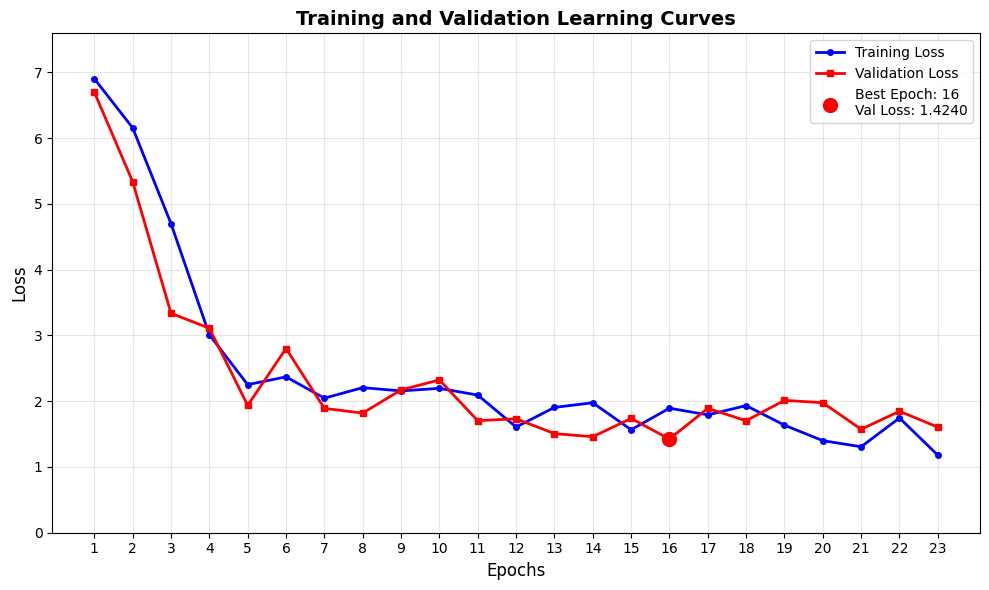


Training Summary:
Best epoch: 16
Best validation loss: 1.4240
Final training loss: 1.1787
Final validation loss: 1.6051


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curves(train_losses, val_losses, save_path=None):
    """
    Plot training and validation learning curves with integer epochs
    """
    plt.figure(figsize=(10, 6))

    epochs = range(1, len(train_losses) + 1)

    # Plot losses
    plt.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2, marker='o', markersize=4)
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=4)

    # Find best validation loss point
    best_epoch_idx = np.argmin(val_losses)
    best_epoch = epochs[best_epoch_idx]
    best_val_loss = val_losses[best_epoch_idx]

    # Mark the best epoch
    plt.scatter(best_epoch, best_val_loss, color='red', s=100, zorder=5,
                label=f'Best Epoch: {best_epoch}\nVal Loss: {best_val_loss:.4f}')

    plt.title('Training and Validation Learning Curves', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    # Set x-axis to integer ticks
    plt.xticks(epochs)

    # Set y-axis to start from 0 for better visualization
    max_loss = max(max(train_losses), max(val_losses))
    plt.ylim(0, max_loss * 1.1)

    # Add some styling
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Learning curves saved to: {save_path}")

    plt.show()

    return best_epoch, best_val_loss

# Plot the learning curves after training
if train_losses and val_losses:
    best_epoch, best_val_loss = plot_learning_curves(
        train_losses,
        val_losses,
        save_path=os.path.join(SAVE_PATH, "learning_curves.png")
    )

    print(f"\nTraining Summary:")
    print(f"Best epoch: {best_epoch}")
    print(f"Best validation loss: {best_val_loss:.4f}")
    print(f"Final training loss: {train_losses[-1]:.4f}")
    print(f"Final validation loss: {val_losses[-1]:.4f}")

In [ ]:
!pip install rouge-score
!pip install bert-score

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score
import matplotlib.pyplot as plt
from collections import Counter

def extract_fields(text):
    """Helper: extract fields from classification format"""
    fields = {}
    if not isinstance(text, str):
        return fields

    for part in text.split(","):
        if ":" in part:
            key, val = part.split(":", 1)
            key = key.strip()
            val = val.strip()
            if key in ["Material", "Kultur", "Kategorie"]:
                fields[key] = val
    return fields

def calculate_classification_metrics(predictions, labels, fields=["Material", "Kultur", "Kategorie"]):
    """Calculate classification metrics for each field"""
    results = {}

    for field in fields:
        y_true, y_pred = [], []

        for pred_text, label_text in zip(predictions, labels):
            if not isinstance(pred_text, str) or not isinstance(label_text, str):
                continue

            pred_fields = extract_fields(pred_text)
            label_fields = extract_fields(label_text)

            true_val = label_fields.get(field, "UNKNOWN")
            pred_val = pred_fields.get(field, "UNKNOWN")

            y_true.append(true_val)
            y_pred.append(pred_val)

        if len(y_true) == 0:
            continue

        # Calculate metrics
        acc = accuracy_score(y_true, y_pred)
        precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )
        precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
            y_true, y_pred, average="weighted", zero_division=0
        )
        precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
            y_true, y_pred, average="micro", zero_division=0
        )

        # Per-class metrics
        unique_classes = sorted(set(y_true))
        precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
            y_true, y_pred, labels=unique_classes, zero_division=0
        )

        results[field] = {
            "accuracy": acc,
            "precision_macro": precision_macro,
            "recall_macro": recall_macro,
            "f1_macro": f1_macro,
            "precision_weighted": precision_weighted,
            "recall_weighted": recall_weighted,
            "f1_weighted": f1_weighted,
            "precision_micro": precision_micro,
            "recall_micro": recall_micro,
            "f1_micro": f1_micro,
            "per_class": {
                cls: {
                    "precision": prec,
                    "recall": rec,
                    "f1": f1,
                    "support": sup
                }
                for cls, prec, rec, f1, sup in zip(unique_classes, precision_per_class,
                                                  recall_per_class, f1_per_class, support)
            },
            "total_samples": len(y_true)
        }

    return results

def calculate_generation_metrics(predictions, labels):
    """Calculate generation metrics for descriptions"""
    if len(predictions) == 0:
        return {}

    # Filter out empty strings and ensure all are strings
    predictions_clean = [str(p) for p in predictions if p and str(p).strip()]
    labels_clean = [str(l) for l in labels if l and str(l).strip()]

    if len(predictions_clean) == 0:
        return {}

    # BLEU Score
    smoothie = SmoothingFunction().method4
    references = [[label.split()] for label in labels_clean]
    candidates = [pred.split() for pred in predictions_clean]

    try:
        bleu_score = corpus_bleu(references, candidates, smoothing_function=smoothie)
    except:
        bleu_score = 0.0

    # ROUGE Scores
    rouge_scorer_obj = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    rouge1_scores, rouge2_scores, rougeL_scores = [], [], []

    for ref, pred in zip(labels_clean, predictions_clean):
        scores = rouge_scorer_obj.score(ref, pred)
        rouge1_scores.append(scores["rouge1"].fmeasure)
        rouge2_scores.append(scores["rouge2"].fmeasure)
        rougeL_scores.append(scores["rougeL"].fmeasure)

    # BERTScore
    try:
        P, R, F1 = bert_score(predictions_clean, labels_clean, lang="de", verbose=False)
        bert_f1 = F1.mean().item()
        bert_precision = P.mean().item()
        bert_recall = R.mean().item()
    except:
        bert_f1 = 0.0
        bert_precision = 0.0
        bert_recall = 0.0

    return {
        "bleu": bleu_score,
        "rouge1": np.mean(rouge1_scores),
        "rouge2": np.mean(rouge2_scores),
        "rougeL": np.mean(rougeL_scores),
        "bertscore_f1": bert_f1,
        "bertscore_precision": bert_precision,
        "bertscore_recall": bert_recall,
        "total_samples": len(predictions_clean)
    }

def separate_classification_description(predictions, labels):
    """Separate classification vs description samples"""
    classification_preds, classification_labels = [], []
    description_preds, description_labels = [], []

    for pred, label in zip(predictions, labels):
        if not isinstance(pred, str) or not isinstance(label, str):
            continue

        # Check if it's a classification sample
        if any(field + ":" in label for field in ["Material", "Kultur", "Kategorie"]):
            classification_preds.append(pred)
            classification_labels.append(label)
        else:
            description_preds.append(pred)
            description_labels.append(label)

    return classification_preds, classification_labels, description_preds, description_labels

def print_detailed_metrics(results, dataset_name):
    """Print formatted metrics"""
    print(f"\n{'='*60}")
    print(f"{dataset_name.upper()} SET METRICS")
    print(f"{'='*60}")

    if "classification" in results and results["classification"]:
        print(f"\n📊 CLASSIFICATION METRICS ({results['classification_samples']} samples)")
        print("-" * 50)

        for field, metrics in results["classification"].items():
            print(f"\n{field}:")
            print(f"  Accuracy:    {metrics['accuracy']:.4f}")
            print(f"  F1 Macro:    {metrics['f1_macro']:.4f}")
            print(f"  F1 Weighted: {metrics['f1_weighted']:.4f}")
            print(f"  Precision:   {metrics['precision_weighted']:.4f}")
            print(f"  Recall:      {metrics['recall_weighted']:.4f}")

            # Show top 3 worst performing classes
            worst_classes = sorted(
                [(cls, data['f1']) for cls, data in metrics['per_class'].items()],
                key=lambda x: x[1]
            )[:3]

            if worst_classes:
                print(f"  Worst classes (F1): {', '.join([f'{cls}({f1:.3f})' for cls, f1 in worst_classes])}")

    if "description" in results and results["description"]:
        print(f"\n📝 DESCRIPTION METRICS ({results['description_samples']} samples)")
        print("-" * 50)
        desc_metrics = results["description"]
        print(f"  BLEU:        {desc_metrics['bleu']:.4f}")
        print(f"  ROUGE-1:     {desc_metrics['rouge1']:.4f}")
        print(f"  ROUGE-2:     {desc_metrics['rouge2']:.4f}")
        print(f"  ROUGE-L:     {desc_metrics['rougeL']:.4f}")
        print(f"  BERTScore F1: {desc_metrics['bertscore_f1']:.4f}")

def evaluate_complete(predictions, labels, dataset_name=""):
    """Complete evaluation function"""
    classification_preds, classification_labels, description_preds, description_labels = separate_classification_description(predictions, labels)

    classification_results = calculate_classification_metrics(classification_preds, classification_labels)
    description_results = calculate_generation_metrics(description_preds, description_labels)

    results = {
        "classification": classification_results,
        "description": description_results,
        "classification_samples": len(classification_labels),
        "description_samples": len(description_labels),
        "total_samples": len(predictions)
    }

    print_detailed_metrics(results, dataset_name)

    return results

# Generate predictions for validation and test sets
def generate_predictions(model, dataloader, processor, device, max_length=150):
    """Generate predictions for a dataloader"""
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Generating predictions"):
            try:
                pixel_values = batch['pixel_values'].to(device).float()
                labels = batch['labels'].to(device)
                image_mask = batch['image_mask'].to(device)
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)

                combined_embeds, combined_attention, labels_padded = process_multiple_images(
                    model, pixel_values, image_mask, input_ids, attention_mask, labels
                )

                # Generate predictions
                generated_ids = model.language_model.generate(
                    inputs_embeds=combined_embeds,
                    attention_mask=combined_attention,
                    max_length=max_length,
                    do_sample=True,
                    top_k=50,
                    top_p=0.95,
                    repetition_penalty=1.2,
                    temperature=0.8
                )

                decoded_preds = processor.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

                # Decode labels
                labels_for_decode = labels.clone()
                labels_for_decode[labels_for_decode == -100] = processor.tokenizer.pad_token_id
                decoded_labels = processor.tokenizer.batch_decode(labels_for_decode, skip_special_tokens=True)

                all_predictions.extend(decoded_preds)
                all_labels.extend(decoded_labels)

            except Exception as e:
                print(f"Prediction batch error: {e}")
                continue

    return all_predictions, all_labels

# Run evaluation on both validation and test sets
print("\n" + "="*80)
print("COMPREHENSIVE MODEL EVALUATION")
print("="*80)

# Validation set evaluation
print("\n🔍 Evaluating on Validation Set...")
val_predictions, val_labels = generate_predictions(model, val_loader, processor, device)
results_val = evaluate_complete(val_predictions, val_labels, "VALIDATION")

# Test set evaluation
print("\n🔍 Evaluating on Test Set...")
test_predictions, test_labels = generate_predictions(model, test_loader, processor, device)
results_test = evaluate_complete(test_predictions, test_labels, "TEST")

# Summary comparison
print("\n" + "="*80)
print("SUMMARY COMPARISON")
print("="*80)

print(f"\nClassification Performance:")
for field in ["Material", "Kultur", "Kategorie"]:
    if field in results_val["classification"] and field in results_test["classification"]:
        val_f1 = results_val["classification"][field]["f1_weighted"]
        test_f1 = results_test["classification"][field]["f1_weighted"]
        print(f"  {field}: Val F1={val_f1:.3f}, Test F1={test_f1:.3f}")

if results_val["description"] and results_test["description"]:
    print(f"\nDescription Performance:")
    print(f"  BLEU:    Val={results_val['description']['bleu']:.3f}, Test={results_test['description']['bleu']:.3f}")
    print(f"  ROUGE-L: Val={results_val['description']['rougeL']:.3f}, Test={results_test['description']['rougeL']:.3f}")
    print(f"  BERT F1: Val={results_val['description']['bertscore_f1']:.3f}, Test={results_test['description']['bertscore_f1']:.3f}")


COMPREHENSIVE MODEL EVALUATION

🔍 Evaluating on Validation Set...


Generating predictions: 100%|██████████| 13/13 [01:28<00:00,  6.78s/it]



VALIDATION SET METRICS

📊 CLASSIFICATION METRICS (23 samples)
--------------------------------------------------

Material:
  Accuracy:    0.9565
  F1 Macro:    0.4889
  F1 Weighted: 0.9353
  Precision:   0.9149
  Recall:      0.9565
  Worst classes (F1): Stein(0.000), Ton(0.978)

Kultur:
  Accuracy:    0.3913
  F1 Macro:    0.1600
  F1 Weighted: 0.2997
  Precision:   0.5202
  Recall:      0.3913
  Worst classes (F1): Korinthisch(0.000), Magna Graecia(0.000), Römisch(0.000)

Kategorie:
  Accuracy:    0.9130
  F1 Macro:    0.3182
  F1 Weighted: 0.8715
  Precision:   0.8336
  Recall:      0.9130
  Worst classes (F1): Architektur / Bauschmuck(0.000), Grossplastik(0.000), Gefäss(0.955)

📝 DESCRIPTION METRICS (26 samples)
--------------------------------------------------
  BLEU:        0.0015
  ROUGE-1:     0.1464
  ROUGE-2:     0.0274
  ROUGE-L:     0.1043
  BERTScore F1: 0.6557

🔍 Evaluating on Test Set...


Generating predictions: 100%|██████████| 13/13 [01:51<00:00,  8.55s/it]



TEST SET METRICS

📊 CLASSIFICATION METRICS (20 samples)
--------------------------------------------------

Material:
  Accuracy:    1.0000
  F1 Macro:    1.0000
  F1 Weighted: 1.0000
  Precision:   1.0000
  Recall:      1.0000
  Worst classes (F1): Ton(1.000)

Kultur:
  Accuracy:    0.3000
  F1 Macro:    0.1408
  F1 Weighted: 0.1986
  Precision:   0.2033
  Recall:      0.3000
  Worst classes (F1): Böotisch(0.000), Korinthisch(0.000), Magna Graecia(0.000)

Kategorie:
  Accuracy:    0.9500
  F1 Macro:    0.4872
  F1 Weighted: 0.9256
  Precision:   0.9025
  Recall:      0.9500
  Worst classes (F1): Kleinplastik(0.000), Gefäss(0.974)

📝 DESCRIPTION METRICS (30 samples)
--------------------------------------------------
  BLEU:        0.0018
  ROUGE-1:     0.1357
  ROUGE-2:     0.0146
  ROUGE-L:     0.0870
  BERTScore F1: 0.6464

SUMMARY COMPARISON

Classification Performance:
  Material: Val F1=0.935, Test F1=1.000
  Kultur: Val F1=0.300, Test F1=0.199
  Kategorie: Val F1=0.872, Test F1=

In [ ]:
def display_samples(predictions, labels, dataset_type="", num_samples=10, show_classification=True, show_description=True):
    """
    Display actual samples with predictions vs ground truth
    """
    classification_preds, classification_labels, description_preds, description_labels = separate_classification_description(predictions, labels)

    print(f"\n{'='*80}")
    print(f"📝 SAMPLE PREDICTIONS - {dataset_type.upper()} SET")
    print(f"{'='*80}")

    if show_classification and classification_preds:
        print(f"\n🎯 CLASSIFICATION SAMPLES ({len(classification_preds)} total):")
        print("-" * 60)

        # Show some random classification samples
        indices = np.random.choice(len(classification_preds), min(num_samples, len(classification_preds)), replace=False)

        for i, idx in enumerate(indices):
            pred = classification_preds[idx]
            label = classification_labels[idx]

            print(f"\nSample {i+1}:")
            print(f"  Ground Truth: {label}")
            print(f"  Prediction:   {pred}")

            # Check if prediction is correct
            pred_fields = extract_fields(pred)
            label_fields = extract_fields(label)

            correct_fields = []
            for field in ["Material", "Kultur", "Kategorie"]:
                pred_val = pred_fields.get(field, "MISSING")
                true_val = label_fields.get(field, "MISSING")
                status = "✅" if pred_val == true_val else "❌"
                correct_fields.append(f"{field}{status}")

            print(f"  Field Match: {', '.join(correct_fields)}")
            print("-" * 40)

    if show_description and description_preds:
        print(f"\n📖 DESCRIPTION SAMPLES ({len(description_preds)} total):")
        print("-" * 60)

        # Show some random description samples
        indices = np.random.choice(len(description_preds), min(num_samples, len(description_preds)), replace=False)

        for i, idx in enumerate(indices):
            pred = description_preds[idx]
            label = description_labels[idx]

            print(f"\nSample {i+1}:")
            print(f"  Ground Truth: {label}")
            print(f"  Prediction:   {pred}")

            # Calculate similarity metrics for this sample
            rouge_scorer_obj = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
            rouge_scores = rouge_scorer_obj.score(label, pred)

            # Calculate BERTScore for semantic similarity - WITHOUT baseline rescaling
            P, R, F1 = bert_score([pred], [label], lang="de", verbose=False)
            bert_f1 = F1.mean().item()

            print(f"  ROUGE-1: {rouge_scores['rouge1'].fmeasure:.3f}")
            print(f"  ROUGE-L: {rouge_scores['rougeL'].fmeasure:.3f}")
            print(f"  BERTScore F1: {bert_f1:.3f}")  # Semantic similarity
            print("-" * 40)

def analyze_common_errors(predictions, labels, dataset_type=""):
    """
    Analyze common error patterns in predictions
    """
    classification_preds, classification_labels, description_preds, description_labels = separate_classification_description(predictions, labels)

    print(f"\n{'='*80}")
    print(f"🔍 ERROR ANALYSIS - {dataset_type.upper()} SET")
    print(f"{'='*80}")

    if classification_preds:
        print(f"\n📊 CLASSIFICATION ERRORS:")
        print("-" * 50)

        error_counts = {field: Counter() for field in ["Material", "Kultur", "Kategorie"]}
        total_errors = 0

        for pred, label in zip(classification_preds, classification_labels):
            pred_fields = extract_fields(pred)
            label_fields = extract_fields(label)

            for field in ["Material", "Kultur", "Kategorie"]:
                pred_val = pred_fields.get(field, "MISSING")
                true_val = label_fields.get(field, "MISSING")

                if pred_val != true_val:
                    error_key = f"{true_val} → {pred_val}"
                    error_counts[field][error_key] += 1
                    total_errors += 1

        for field in ["Material", "Kultur", "Kategorie"]:
            if error_counts[field]:
                print(f"\n{field} Errors (Top 5):")
                for error, count in error_counts[field].most_common(5):
                    print(f"  {error}: {count} times")

    if description_preds:
        print(f"\n📝 DESCRIPTION QUALITY ANALYSIS:")
        print("-" * 50)

        # Calculate length statistics
        pred_lengths = [len(pred.split()) for pred in description_preds]
        label_lengths = [len(label.split()) for label in description_labels]

        # Calculate BERTScore statistics - WITHOUT baseline rescaling
        P, R, F1 = bert_score(description_preds, description_labels, lang="de", verbose=False)
        bert_f1_scores = F1.tolist()

        print(f"  Avg prediction length: {np.mean(pred_lengths):.1f} words")
        print(f"  Avg ground truth length: {np.mean(label_lengths):.1f} words")
        print(f"  Length ratio: {np.mean(pred_lengths)/np.mean(label_lengths):.2f}")
        print(f"  Avg BERTScore F1: {np.mean(bert_f1_scores):.3f} ± {np.std(bert_f1_scores):.3f}")
        print(f"  BERTScore range: {np.min(bert_f1_scores):.3f} - {np.max(bert_f1_scores):.3f}")

def show_performance_by_class(predictions, labels, dataset_type=""):
    """
    Show performance breakdown by class for classification tasks
    """
    classification_preds, classification_labels, _, _ = separate_classification_description(predictions, labels)

    if not classification_preds:
        return

    print(f"\n{'='*80}")
    print(f"📈 CLASS-WISE PERFORMANCE - {dataset_type.upper()} SET")
    print(f"{'='*80}")

    for field in ["Material", "Kultur", "Kategorie"]:
        y_true, y_pred = [], []

        for pred_text, label_text in zip(classification_preds, classification_labels):
            pred_fields = extract_fields(pred_text)
            label_fields = extract_fields(label_text)

            true_val = label_fields.get(field, "UNKNOWN")
            pred_val = pred_fields.get(field, "UNKNOWN")

            y_true.append(true_val)
            y_pred.append(pred_val)

        # Calculate per-class metrics
        unique_classes = sorted(set(y_true))
        precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
            y_true, y_pred, labels=unique_classes, zero_division=0
        )

        print(f"\n{field} Performance:")
        print(f"{'Class':<25} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
        print("-" * 65)

        for cls, prec, rec, f1, sup in zip(unique_classes, precision_per_class, recall_per_class, f1_per_class, support):
            print(f"{cls:<25} {prec:<10.3f} {rec:<10.3f} {f1:<10.3f} {sup:<10}")

        # Show best and worst performing classes
        class_performance = [(cls, f1, sup) for cls, f1, sup in zip(unique_classes, f1_per_class, support)]
        best_classes = sorted(class_performance, key=lambda x: x[1], reverse=True)[:3]
        worst_classes = sorted(class_performance, key=lambda x: x[1])[:3]

        print(f"\n  🏆 Best: {', '.join([f'{cls}({f1:.3f})' for cls, f1, _ in best_classes])}")
        print(f"  ⚠️  Worst: {', '.join([f'{cls}({f1:.3f})' for cls, f1, _ in worst_classes])}")

# Run the sample analysis
print("\n" + "="*100)
print("🧪 DETAILED SAMPLE ANALYSIS")
print("="*100)

# Validation set samples
print("\n1. VALIDATION SET ANALYSIS:")
display_samples(val_predictions, val_labels, "validation", num_samples=8)
analyze_common_errors(val_predictions, val_labels, "validation")
show_performance_by_class(val_predictions, val_labels, "validation")

# Test set samples
print("\n2. TEST SET ANALYSIS:")
display_samples(test_predictions, test_labels, "test", num_samples=8)
analyze_common_errors(test_predictions, test_labels, "test")
show_performance_by_class(test_predictions, test_labels, "test")

# Show some interesting cases
def show_interesting_cases(predictions, labels, dataset_type=""):
    """
    Show particularly good and bad cases
    """
    print(f"\n{'='*80}")
    print(f"🎯 INTERESTING CASES - {dataset_type.upper()} SET")
    print(f"{'='*80}")

    # Find best and worst classification samples
    classification_preds, classification_labels, description_preds, description_labels = separate_classification_description(predictions, labels)

    if classification_preds:
        print(f"\n🎯 CLASSIFICATION - BEST/WORST CASES:")

        sample_scores = []
        for i, (pred, label) in enumerate(zip(classification_preds, classification_labels)):
            pred_fields = extract_fields(pred)
            label_fields = extract_fields(label)

            correct_count = 0
            total_fields = 0
            for field in ["Material", "Kultur", "Kategorie"]:
                if field in label_fields:
                    total_fields += 1
                    if pred_fields.get(field) == label_fields.get(field):
                        correct_count += 1

            accuracy = correct_count / total_fields if total_fields > 0 else 0
            sample_scores.append((i, accuracy, pred, label))

        # Show best cases
        print(f"\n🏅 BEST PREDICTIONS (perfect matches):")
        perfect_matches = [s for s in sample_scores if s[1] == 1.0]
        for i, (idx, acc, pred, label) in enumerate(perfect_matches[:3]):
            print(f"\n  Sample {i+1}:")
            print(f"    Truth: {label}")
            print(f"    Pred:  {pred}")

        # Show worst cases
        print(f"\n💥 WORST PREDICTIONS (no matches):")
        worst_matches = [s for s in sample_scores if s[1] == 0.0]
        for i, (idx, acc, pred, label) in enumerate(worst_matches[:3]):
            print(f"\n  Sample {i+1}:")
            print(f"    Truth: {label}")
            print(f"    Pred:  {pred}")

    # Add description interesting cases with BERTScore
    if description_preds:
        print(f"\n📖 DESCRIPTION - BEST/WORST CASES BY SEMANTIC SIMILARITY:")

        desc_scores = []
        for i, (pred, label) in enumerate(zip(description_preds, description_labels)):
            P, R, F1 = bert_score([pred], [label], lang="de", verbose=False)
            bert_f1 = F1.mean().item()
            desc_scores.append((i, bert_f1, pred, label))

        # Show best semantic matches
        desc_scores.sort(key=lambda x: x[1], reverse=True)
        print(f"\n🏅 BEST SEMANTIC MATCHES:")
        for i, (idx, score, pred, label) in enumerate(desc_scores[:3]):
            print(f"\n  Sample {idx+1} (BERTScore: {score:.3f}):")
            print(f"    Truth: {label}")
            print(f"    Pred:  {pred}")

        # Show worst semantic matches
        print(f"\n💥 WORST SEMANTIC MATCHES:")
        for i, (idx, score, pred, label) in enumerate(desc_scores[-3:]):
            print(f"\n  Sample {idx+1} (BERTScore: {score:.3f}):")
            print(f"    Truth: {label}")
            print(f"    Pred:  {pred}")

# Show interesting cases
show_interesting_cases(val_predictions, val_labels, "validation")
show_interesting_cases(test_predictions, test_labels, "test")


🧪 DETAILED SAMPLE ANALYSIS

1. VALIDATION SET ANALYSIS:

📝 SAMPLE PREDICTIONS - VALIDATION SET

🎯 CLASSIFICATION SAMPLES (23 total):
------------------------------------------------------------

Sample 1:
  Ground Truth: Material: Ton, Kultur: Korinthisch, Kategorie: Gefäss
  Prediction:   Material: Ton, Kultur: Apulisch, Kategorie: Gefäss
  Field Match: Material✅, Kultur❌, Kategorie✅
----------------------------------------

Sample 2:
  Ground Truth: Material: Ton, Kultur: Korinthisch, Kategorie: Gefäss
  Prediction:   Material: Ton, Kultur: Kampanisch, Kategorie: Gefäss
  Field Match: Material✅, Kultur❌, Kategorie✅
----------------------------------------

Sample 3:
  Ground Truth: Material: Ton, Kultur: Kampanisch, Kategorie: Gefäss
  Prediction:   Material: Ton, Kultur: Kampanisch, Kategorie: Gefäss
  Field Match: Material✅, Kultur✅, Kategorie✅
----------------------------------------

Sample 4:
  Ground Truth: Material: Ton, Kultur: Attisch, Kategorie: Gefäss
  Prediction:   Mate